### A "Thin" Application of Time Series

Google Trends allows users to see how often a term is searched for. We downloaded a file from Google Trends containing the frequency over time for the search word "diet", which is pre-loaded in a DataFrame called diet. A first step when analyzing a time series is to visualize the data with a plot. You should be able to clearly see a gradual decrease in searches for "diet" throughout the calendar year, hitting a low around the December holidays, followed by a spike in searches around the new year as people make New Year's resolutions to lose weight.

Like many time series datasets you will be working with, the index of dates are strings and should be converted to a datetime index before plotting.

Convert the date index to datetime using pandas's to_datetime().

In [ ]:
# Import pandas and plotting modules
import pandas as pd
import matplotlib.pyplot as plt

# Convert the date index to datetime
diet.index = pd.to_datetime(diet.index)

Plot the time series and set the argument grid to True to better see the year-ends.

In [ ]:
# Plot the entire time series diet and show gridlines
diet.plot(grid=True)
plt.show()

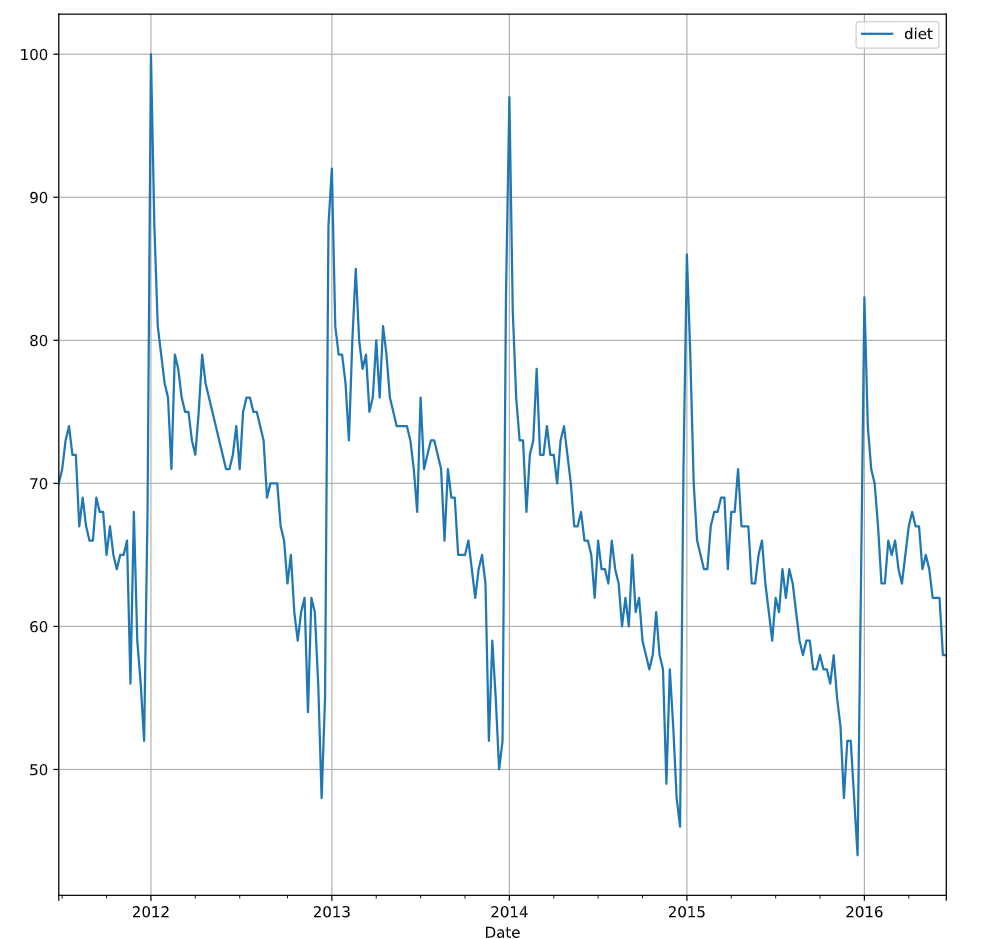

In [ ]:
# Slice the dataset to keep only 2012
diet2012 = diet['2012']

# Plot 2012 data
diet2012.plot(grid=True)
plt.show()

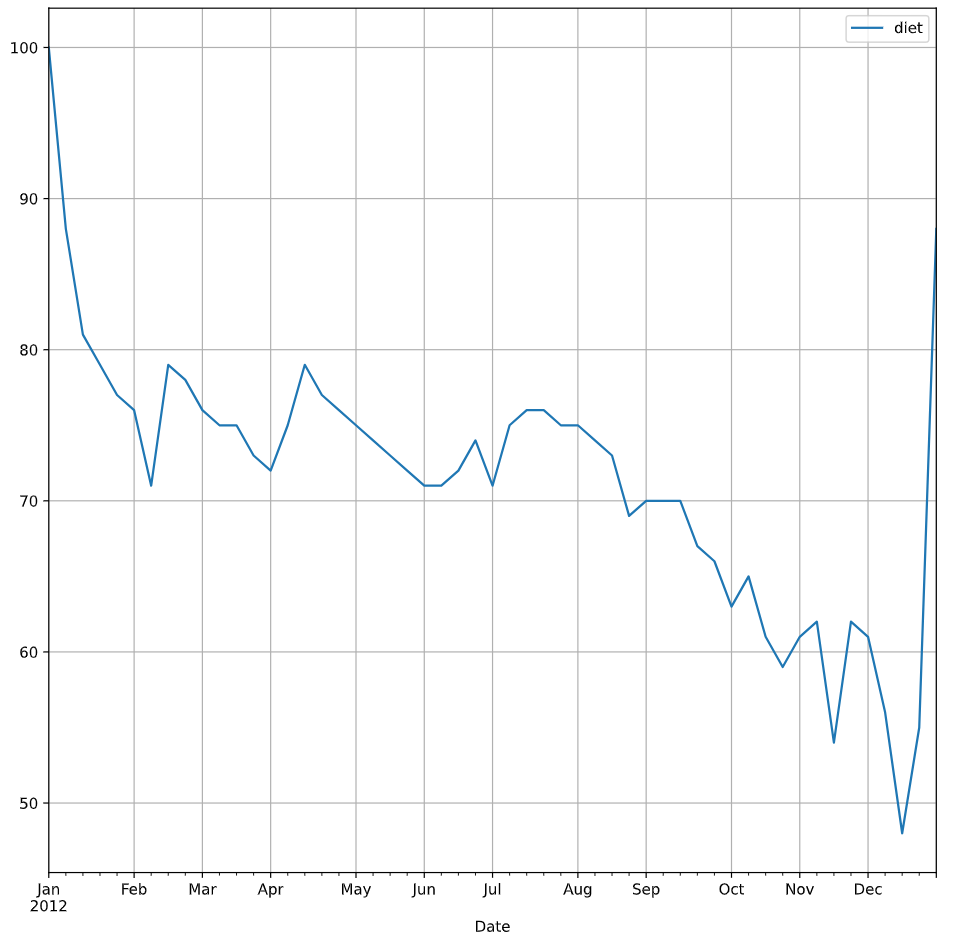

### Merging Time Series With Different Dates
Stock and bond markets in the U.S. are closed on different days. For example, although the bond market is closed on Columbus Day (around Oct 12) and Veterans Day (around Nov 11), the stock market is open on those days. One way to see the dates that the stock market is open and the bond market is closed is to convert both indexes of dates into sets and take the difference in sets.

The pandas .join() method is a convenient tool to merge the stock and bond DataFrames on dates when both markets are open.

Stock prices and 10-year US Government bond yields, which were downloaded from FRED, are pre-loaded in DataFrames stocks and bonds.

- Convert the dates in the stocks.index and bonds.index into sets.
- Take the difference of the stock set minus the bond set to get those dates where the stock market has data but the bond market does not.
- Merge the two DataFrames into a new DataFrame, stocks_and_bonds using the .join() method, which has the syntax df1.join(df2).

      - To get the intersection of dates, use the argument how='inner'.

In [ ]:
# Import pandas
import pandas as pd

# Convert the stock index and bond index into sets
set_stock_dates = set(stocks.index)
set_bond_dates = set(bonds.index)

# Take the difference between the sets and print
print(set_stock_dates - set_bond_dates)

# Merge stocks and bonds DataFrames using join()
stocks_and_bonds = stocks.join(bonds, how='inner')

#correct output: 
{'2015-10-12', '2016-10-10', '2017-06-09', '2009-11-11', '2015-11-11', '2012-10-08', '2013-10-14', '2008-11-11', '2007-10-08', '2011-10-10', '2010-10-11', '2013-11-11', '2014-11-11', '2014-10-13', '2007-11-12', '2012-11-12', '2009-10-12', '2011-11-11', '2008-10-13', '2010-11-11', '2016-11-11'}